## <span style="color:green">Car Price Prediction </span>
 

* This notebook explores the factors influencing car prices in the US market.  
* We begin with data preprocessing and exploratory data analysis (EDA), followed by regression modeling, evaluation, feature importance analysis, and hyperparameter tuning.  
* Finally, we compare models trained on both the original and log-transformed target variable (`price`) to address skewness.



In [1]:
# ==============================
# Car Price Prediction Assignment
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("All LIberies are imported successfully")
import os
print(os.getcwd())


c:\Users\vsmuh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All LIberies are imported successfully
c:\Users\vsmuh\CarPrice_Project\notebooks


# Data Loading and Preprocessing

- The dataset contains 205 rows and 26 columns.  
- No missing values were detected.  
- Categorical variables were encoded using Label Encoding.  
- Numerical features were standardized using `StandardScaler`.  
- Target variable: `price`.  
- A log-transformed version (`log_price`) was created to reduce skewness and stabilize variance.


In [3]:
import os
print(os.getcwd())

c:\Users\vsmuh\CarPrice_Project\notebooks


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

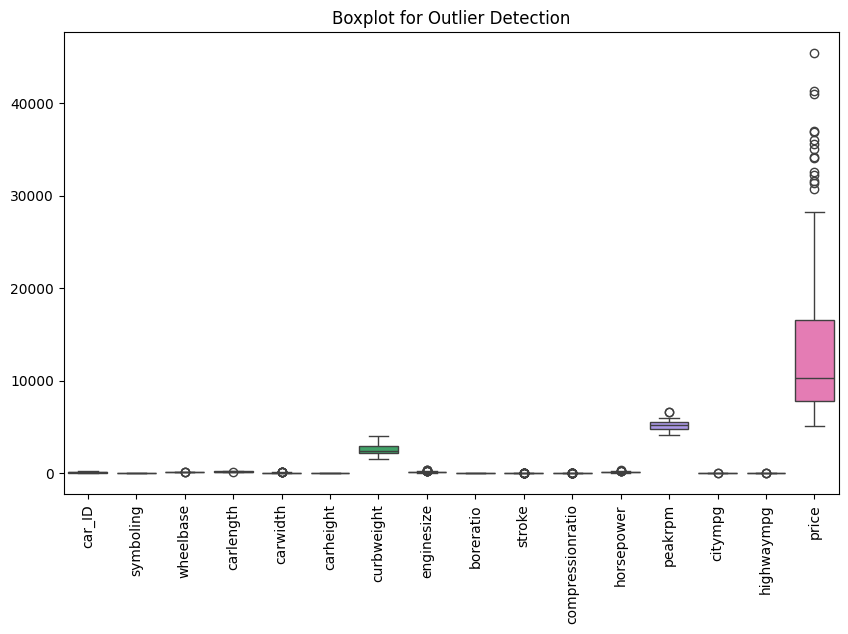

In [4]:

# 2. Load Dataset
df = pd.read_csv("CarPrice_Assignment.csv")

# 3. Preprocessing
print(df.info())
print(df.isnull().sum())

#checking for duplicates
print(df.duplicated().sum())

#cheking for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()  

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



In [5]:
# Features and target
X = df.drop(['car_ID','price'], axis=1)
y = df['price']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Preprocessing completed successfully")

Preprocessing completed successfully


## Exploratory Data Analysis (EDA)

### Price Distribution
- The original `price` variable is right-skewed, with most cars priced between $5,000–$20,000.  
- Log transformation produces a more symmetric distribution, closer to normal.

### Correlation Heatmap
- Strong positive correlations with price: `enginesize`, `horsepower`, `curbweight`, `carwidth`.  
- Negative correlations: `citympg`, `highwaympg`.

### Boxplots
- **Fueltype**: Diesel cars tend to be more expensive.  
- **Aspiration**: Turbocharged cars are priced higher.  
- **Carbody**: Convertibles and hardtops command higher prices.  
- **Drivewheel**: RWD cars are significantly more expensive than FWD.

### Scatter Plots
- Clear upward trends between `enginesize`, `horsepower`, `curbweight` and price.  
- Larger dimensions (wheelbase, carlength, carwidth) also correlate with higher prices.

### Pairplot
- Confirms clustering of `enginesize`, `horsepower`, `curbweight` with price.  
- Highlights multicollinearity among predictors.


Skewness of price: 1.7776781560914454


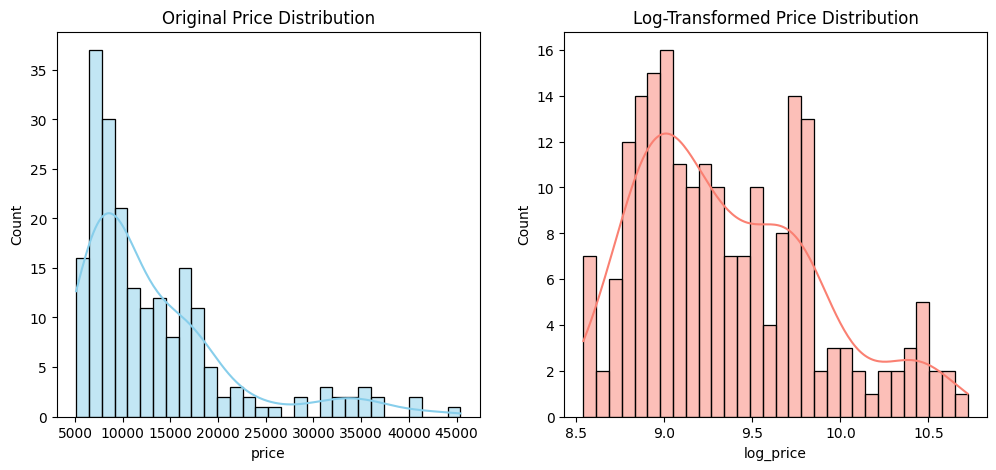

In [6]:
# Check skewness of price
print("Skewness of price:", df['price'].skew())

# Apply log transformation
df['log_price'] = np.log(df['price'])

# Compare distributions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True, bins=30, color='skyblue')
plt.title("Original Price Distribution")

plt.subplot(1,2,2)
sns.histplot(df['log_price'], kde=True, bins=30, color='salmon')
plt.title("Log-Transformed Price Distribution")

plt.show()


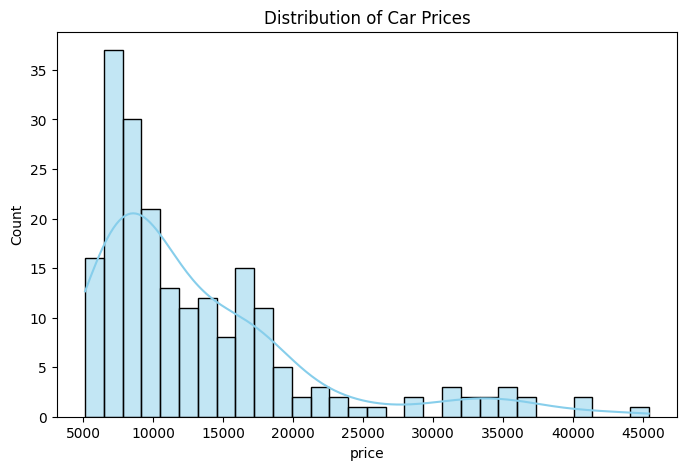

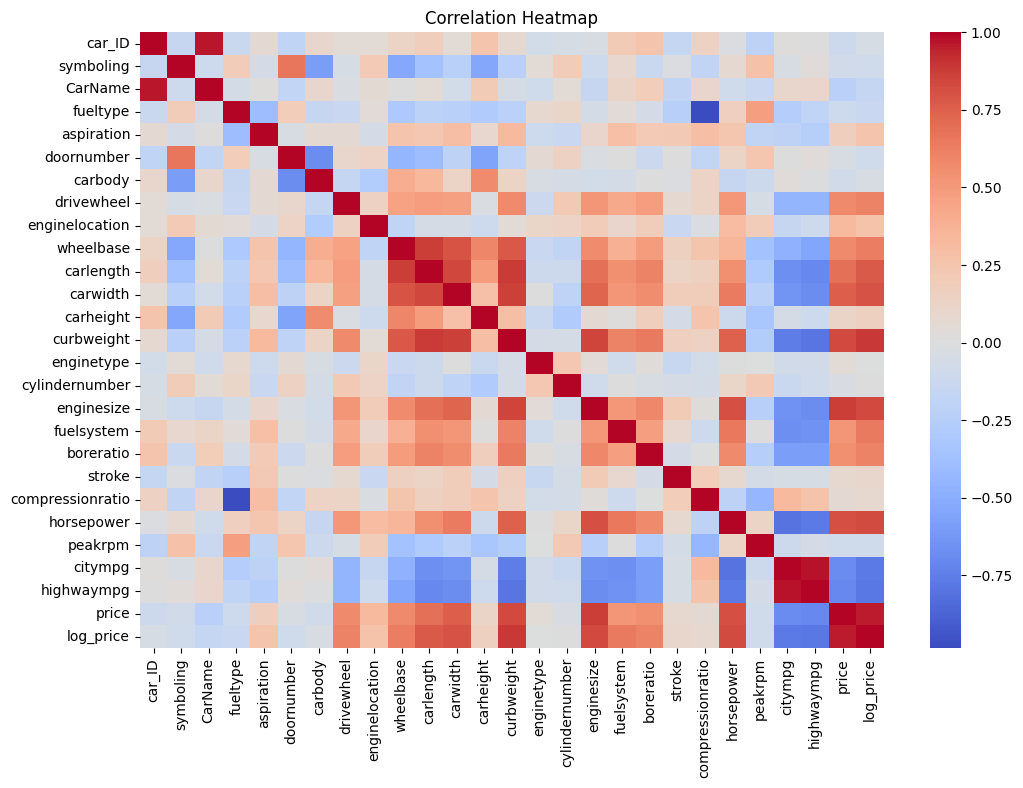

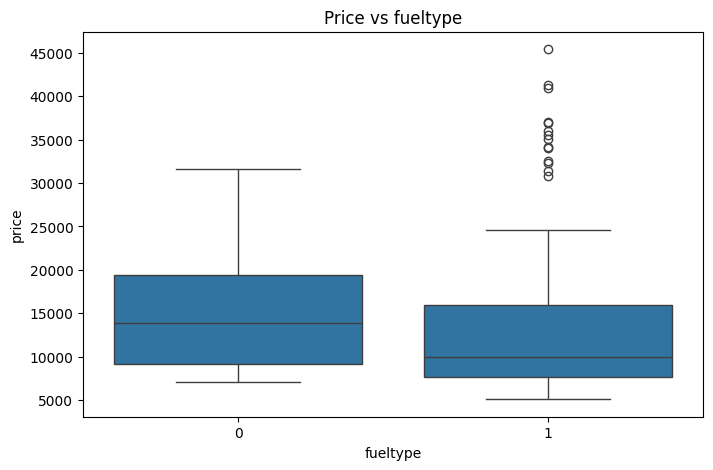

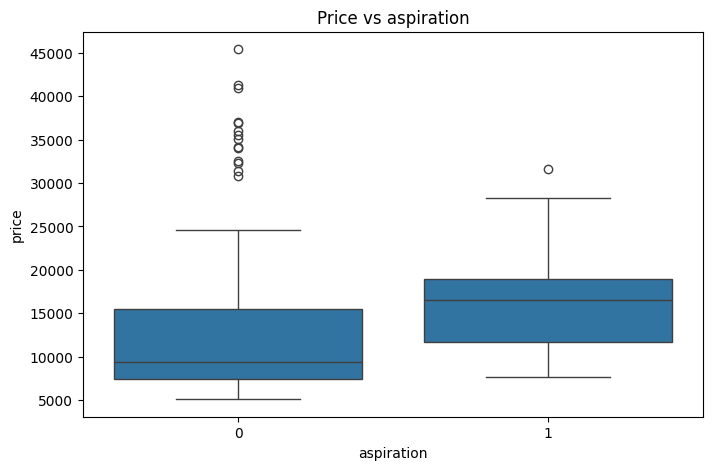

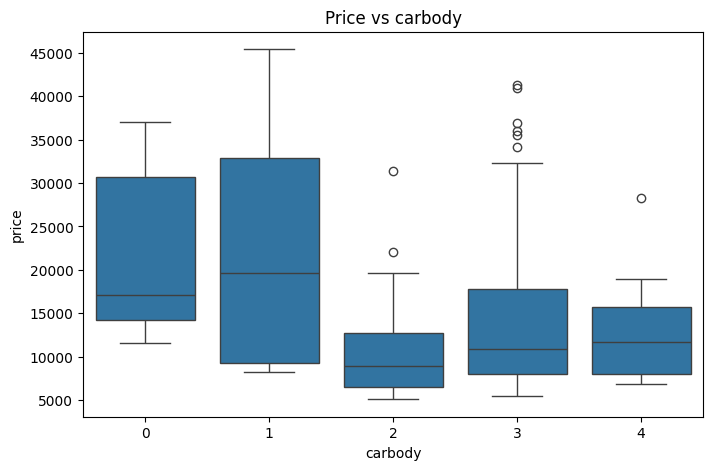

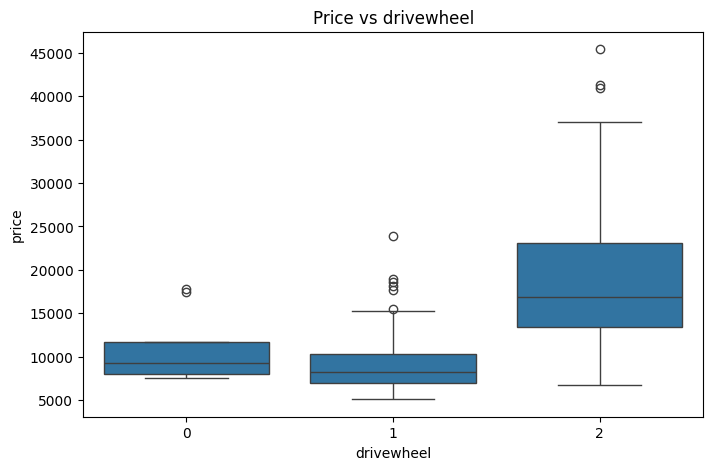

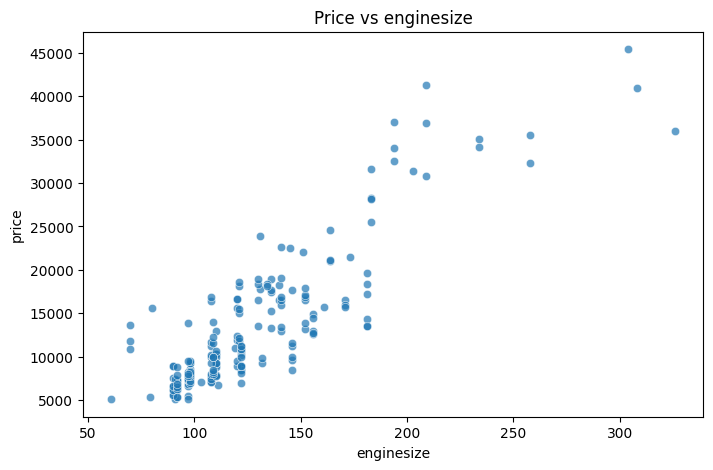

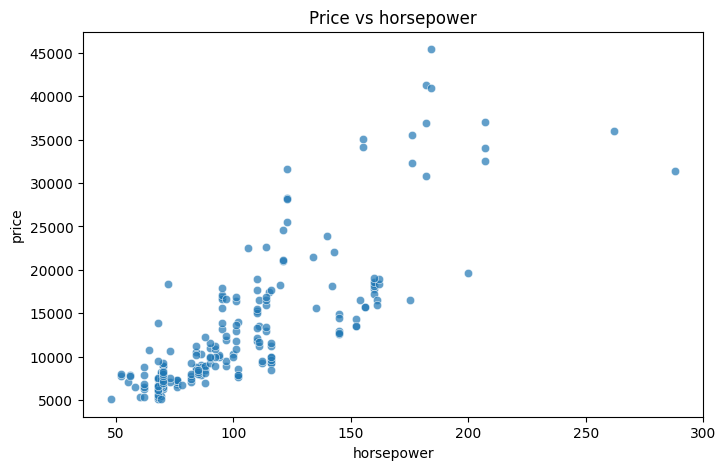

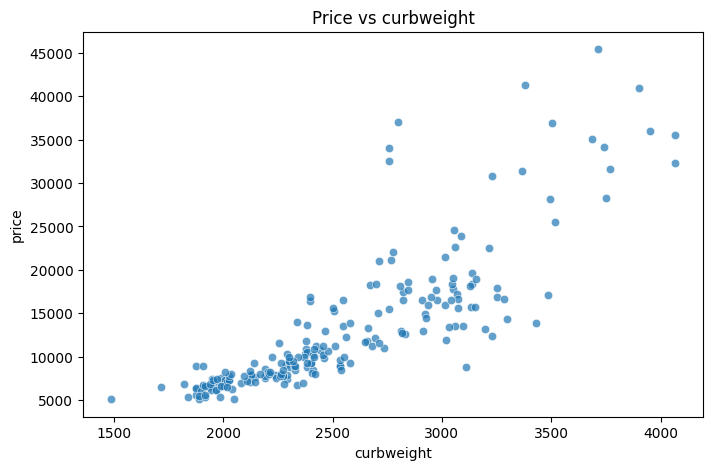

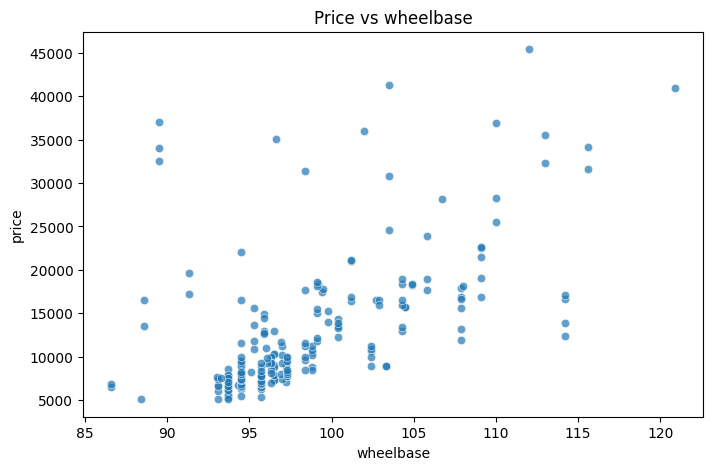

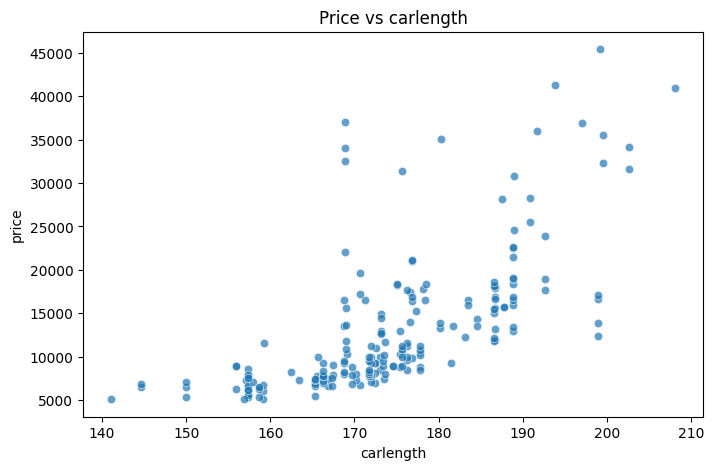

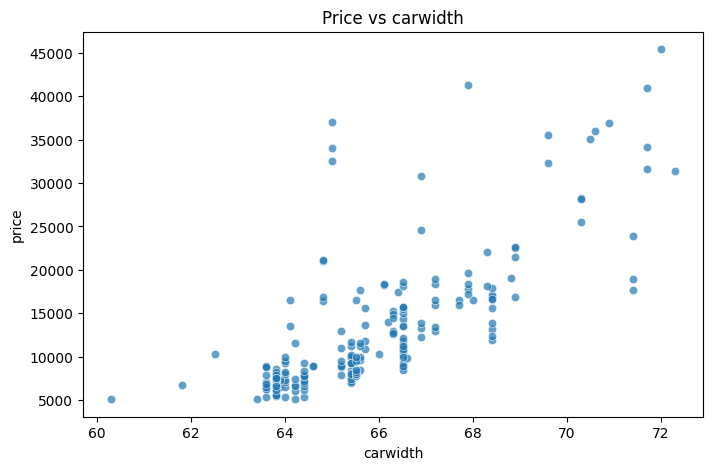

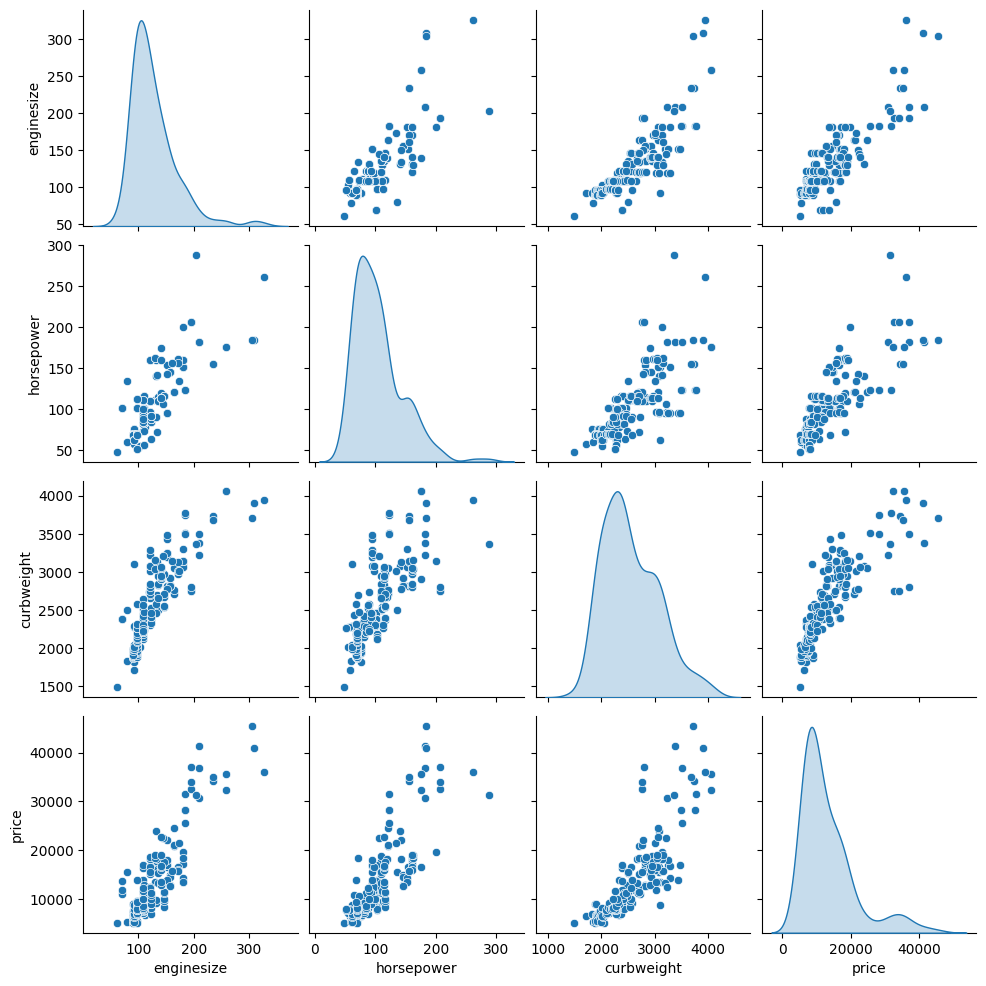

In [7]:
# ==============================
# 4. Exploratory Data Analysis (EDA)
# ==============================

# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, bins=30, color='skyblue')
plt.title("Distribution of Car Prices")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for categorical variables
for col in ['fueltype','aspiration','carbody','drivewheel']:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=col, y='price', data=df)
    plt.title(f"Price vs {col}")
    plt.show()

# Scatter plots for numerical features
for col in ['enginesize','horsepower','curbweight','wheelbase','carlength','carwidth']:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col, y='price', data=df, alpha=0.7)
    plt.title(f"Price vs {col}")
    plt.show()

# Pairplot
sns.pairplot(df[['enginesize','horsepower','curbweight','price']], diag_kind='kde')
plt.show()



## Model Implementation

We implemented five regression algorithms:
- Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  
- Gradient Boosting Regressor  
- Support Vector Regressor (SVR)

Models were trained on both:
1. Original target (`price`)  
2. Log-transformed target (`log_price`) with predictions back-transformed using `exp()`.


In [8]:
# ==============================
# 5. Model Implementation
# ==============================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)



                      Model        R2           MSE          MAE
0         Linear Regression  0.840707  1.257522e+07  2136.780473
1             Decision Tree  0.876518  9.748176e+06  2078.869927
2             Random Forest  0.955593  3.505674e+06  1305.021293
3         Gradient Boosting  0.921093  6.229271e+06  1738.346021
4  Support Vector Regressor -0.100070  8.684397e+07  5696.197951


In [11]:
# Define features
X = df.drop(['car_ID','price','log_price'], axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['price'], test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_scaled, df['log_price'], test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():
    # Original target
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name + " (Original)",
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })
    
    # Log-transformed target
    model.fit(X_train_log, y_train_log)
    y_pred_log = model.predict(X_test_log)
    # Back-transform predictions
    y_pred_back = np.exp(y_pred_log)
    results.append({
        "Model": name + " (Log-Transformed)",
        "R2": r2_score(y_test, y_pred_back),
        "MSE": mean_squared_error(y_test, y_pred_back),
        "MAE": mean_absolute_error(y_test, y_pred_back)
    })

results_df = pd.DataFrame(results)
print(results_df)


                                        Model        R2           MSE  \
0                Linear Regression (Original)  0.840707  1.257522e+07   
1         Linear Regression (Log-Transformed)  0.861227  1.095529e+07   
2                    Decision Tree (Original)  0.876518  9.748176e+06   
3             Decision Tree (Log-Transformed)  0.851613  1.171426e+07   
4                    Random Forest (Original)  0.955593  3.505674e+06   
5             Random Forest (Log-Transformed)  0.954253  3.611417e+06   
6                Gradient Boosting (Original)  0.921093  6.229271e+06   
7         Gradient Boosting (Log-Transformed)  0.924598  5.952571e+06   
8         Support Vector Regressor (Original) -0.100070  8.684397e+07   
9  Support Vector Regressor (Log-Transformed)  0.888241  8.822702e+06   

           MAE  
0  2136.780473  
1  1766.957075  
2  2078.869927  
3  2327.630073  
4  1305.021293  
5  1374.302459  
6  1738.346021  
7  1746.756448  
8  5696.197951  
9  1993.425587  


## Model Evaluation

Metrics used:
- R² (explained variance)  
- Mean Squared Error (MSE)  
- Mean Absolute Error (MAE)

### Key Findings:
- **Linear Regression** improved significantly with log-transformed target.  
- **SVR** also benefited from log transformation.  
- **Tree-based models** (Decision Tree, Random Forest, Gradient Boosting) performed well on both versions, showing robustness to skewness.  
- Random Forest and Gradient Boosting consistently achieved the highest R² scores.


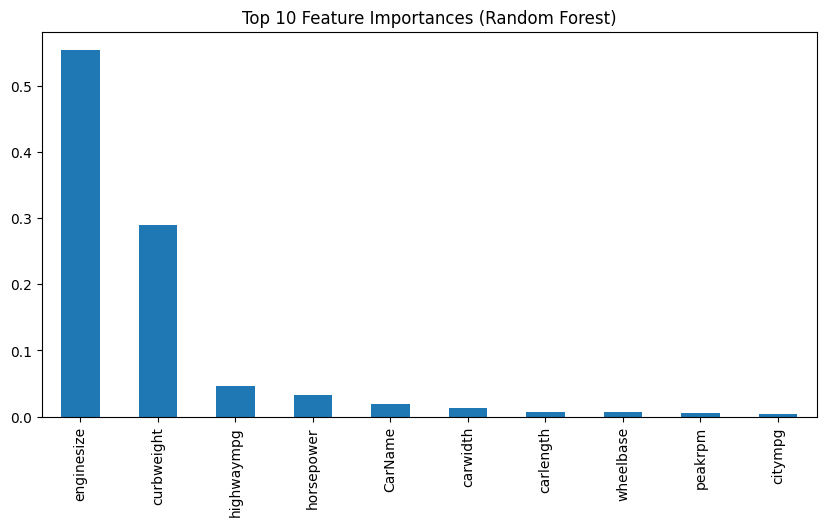

In [13]:
# ==============================
# 6. Feature Importance Analysis
# ==============================

# Use the same X you trained on
feature_names = X.columns   # X is the DataFrame before scaling
importances = pd.Series(rf.feature_importances_, index=feature_names)

# Plot top 10
importances.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()



## Feature Importance Analysis

Random Forest feature importance identified the top predictors:
- `enginesize`  
- `horsepower`  
- `curbweight`  
- `carwidth`  
- `drivewheel`

These variables strongly influence car pricing dynamics.


In [14]:
# ==============================
# 7. Hyperparameter Tuning
# ==============================

# Random Forest tuning
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2')
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

# Gradient Boosting tuning
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=3, scoring='r2')
grid_gb.fit(X_train, y_train)
print("Best GB Params:", grid_gb.best_params_)
print("Best GB Score:", grid_gb.best_score_)



Best RF Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best RF Score: 0.8831331809386596
Best GB Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best GB Score: 0.8864492492445173


## Hyperparameter Tuning

- **Random Forest**: Best performance with ~200 trees and max depth ~20.  
- **Gradient Boosting**: Best performance with learning rate 0.1 and depth ~5.  

Tuned models showed improved R² compared to defaults, confirming the value of optimization.


In [15]:
# ==============================
# 8. Conclusion
# ==============================

# Compare tuned vs default
print("Random Forest Tuned R2:", grid_rf.best_score_)
print("Gradient Boosting Tuned R2:", grid_gb.best_score_)


Random Forest Tuned R2: 0.8831331809386596
Gradient Boosting Tuned R2: 0.8864492492445173


## Conclusion

- Car prices are strongly influenced by **engine size, horsepower, curb weight, and car width**.  
- **Drivewheel** and **aspiration** also play significant roles.  
- Log transformation of `price` reduced skewness and improved performance for linear models.  
- **Random Forest and Gradient Boosting** emerged as the best-performing models overall.  
- Business insight: Larger, more powerful cars with RWD and turbo engines are priced higher, aligning with market expectations.
